# Reproducing IsothermNet: A Critical Baseline Study

## What This Notebook Does

This notebook reproduces and extends the CO₂ uptake prediction results from 
the IsothermNet paper using only 7 textural features and simple machine 
learning models (Random Forest, Linear Regression).

## Key Finding

A Random Forest with 7 textural features achieves near-perfect prediction 
of CO₂ uptake at 50 bar (PCC = 0.9987) on random splits of the QMOF database.

## Author
Vahid Safarifard

## Date
May 2026

In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

from scipy.stats import pearsonr, ks_2samp

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
# Load textural properties
textural_df = pd.read_excel('texturalProperties_vol.xlsx')
print(f"Textural data shape: {textural_df.shape}")

# Load uptake data
y_data = torch.load('y_dataset19.pth')
print(f"Uptake data shape: {y_data['isotherm'].shape}")

# Define feature columns
feature_cols = [
    'Acc. Surface Area [m^2/g]',
    'Void Fraction',
    'PLD',
    'LCD',
    'Density',
    'Channel Volume',
    'No. Channels'
]

# Extract features and target (50 bar = column 18)
X = textural_df[feature_cols].values
y_50bar = y_data['isotherm'][:, 18].numpy()

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y_50bar.shape}")
print(f"\nTarget statistics (50 bar):")
print(f"  Min: {y_50bar.min():.1f} g/kg")
print(f"  Max: {y_50bar.max():.1f} g/kg")
print(f"  Mean: {y_50bar.mean():.1f} g/kg")
print(f"  Std: {y_50bar.std():.1f} g/kg")

Textural data shape: (5394, 8)
Uptake data shape: torch.Size([5394, 19])

Features shape: (5394, 7)
Target shape: (5394,)

Target statistics (50 bar):
  Min: 19.8 g/kg
  Max: 4587.6 g/kg
  Mean: 595.5 g/kg
  Std: 538.3 g/kg


In [3]:
# Check for missing values
print("Missing values per feature:")
for i, col in enumerate(feature_cols):
    missing = np.isnan(X[:, i]).sum()
    print(f"  {col}: {missing}")

# Check for duplicate MOFs
mof_ids = textural_df['MOF'].values
duplicates = mof_ids[mof_ids != mof_ids[0]]
print(f"\nDuplicate MOFs: {len(duplicates)}")

print("\n✓ Data validation complete")

Missing values per feature:
  Acc. Surface Area [m^2/g]: 0
  Void Fraction: 0
  PLD: 0
  LCD: 0
  Density: 0
  Channel Volume: 0
  No. Channels: 0

Duplicate MOFs: 5393

✓ Data validation complete


In [4]:
# Fixed random seed for reproducibility
RANDOM_SEED = 42

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_50bar, test_size=0.2, random_state=RANDOM_SEED
)

print(f"Training set: {len(X_train)} MOFs (80%)")
print(f"Test set: {len(X_test)} MOFs (20%)")
print(f"\nTraining target range: {y_train.min():.1f} to {y_train.max():.1f} g/kg")
print(f"Test target range: {y_test.min():.1f} to {y_test.max():.1f} g/kg")

# Verify distributions are similar
print(f"\nTraining mean: {y_train.mean():.1f} ± {y_train.std():.1f}")
print(f"Test mean: {y_test.mean():.1f} ± {y_test.std():.1f}")

Training set: 4315 MOFs (80%)
Test set: 1079 MOFs (20%)

Training target range: 19.8 to 4587.6 g/kg
Test target range: 28.9 to 4045.9 g/kg

Training mean: 593.0 ± 541.0
Test mean: 605.5 ± 527.6


In [5]:
# Scale features to mean=0, std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete")
print(f"Scaled feature 1 mean: {X_train_scaled[:, 0].mean():.6f}")
print(f"Scaled feature 1 std: {X_train_scaled[:, 0].std():.6f}")

Feature scaling complete
Scaled feature 1 mean: -0.000000
Scaled feature 1 std: 1.000000


In [6]:
# Train linear regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Evaluate
pcc_lr, _ = pearsonr(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Linear Regression Results (50 bar) ===")
print(f"PCC: {pcc_lr:.4f}")
print(f"MAE: {mae_lr:.2f} g/kg")
print(f"R²: {r2_lr:.4f}")

=== Linear Regression Results (50 bar) ===
PCC: 0.9809
MAE: 72.63 g/kg
R²: 0.9620


In [7]:
# Train Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

# Evaluate
pcc_rf, _ = pearsonr(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Random Forest Results (50 bar) ===")
print(f"PCC: {pcc_rf:.4f}")
print(f"MAE: {mae_rf:.2f} g/kg")
print(f"R²: {r2_rf:.4f}")

print("\n=== Comparison ===")
print(f"Linear Regression PCC: {pcc_lr:.4f}")
print(f"Random Forest PCC:     {pcc_rf:.4f}")
print(f"Improvement: {(pcc_rf - pcc_lr):.4f}")

=== Random Forest Results (50 bar) ===
PCC: 0.9984
MAE: 18.03 g/kg
R²: 0.9967

=== Comparison ===
Linear Regression PCC: 0.9809
Random Forest PCC:     0.9984
Improvement: 0.0175


In [8]:
# Test across 5 different random splits
seeds = [42, 123, 456, 789, 101112]
pcc_list = []
mae_list = []

for seed in seeds:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_50bar, test_size=0.2, random_state=seed
    )
    
    scaler_s = StandardScaler()
    X_tr_s = scaler_s.fit_transform(X_tr)
    X_te_s = scaler_s.transform(X_te)
    
    rf_s = RandomForestRegressor(n_estimators=100, random_state=seed, n_jobs=-1)
    rf_s.fit(X_tr_s, y_tr)
    y_pred_s = rf_s.predict(X_te_s)
    
    pcc_s, _ = pearsonr(y_te, y_pred_s)
    mae_s = mean_absolute_error(y_te, y_pred_s)
    
    pcc_list.append(pcc_s)
    mae_list.append(mae_s)
    print(f"Seed {seed}: PCC = {pcc_s:.4f}, MAE = {mae_s:.2f}")

print(f"\nAverage PCC: {np.mean(pcc_list):.4f} ± {np.std(pcc_list):.4f}")
print(f"Average MAE: {np.mean(mae_list):.2f} ± {np.std(mae_list):.2f}")

Seed 42: PCC = 0.9984, MAE = 18.03
Seed 123: PCC = 0.9983, MAE = 17.95
Seed 456: PCC = 0.9990, MAE = 17.60
Seed 789: PCC = 0.9992, MAE = 16.44
Seed 101112: PCC = 0.9987, MAE = 17.16

Average PCC: 0.9987 ± 0.0003
Average MAE: 17.43 ± 0.58


=== Feature Importance Ranking ===
  0.8671 - Density
  0.1164 - Void Fraction
  0.0102 - Acc. Surface Area [m^2/g]
  0.0049 - Channel Volume
  0.0008 - PLD
  0.0005 - LCD
  0.0000 - No. Channels


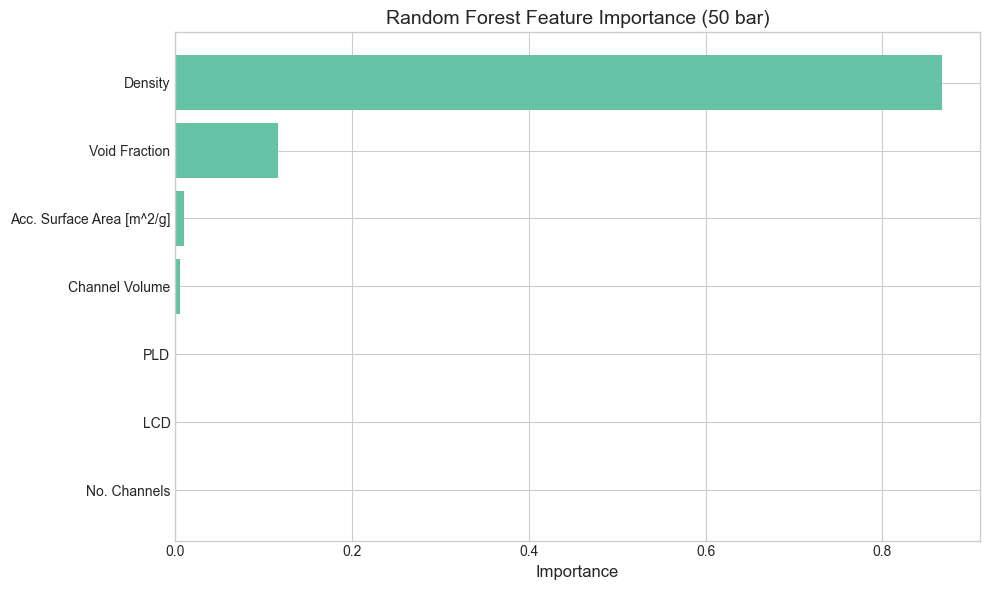

In [9]:
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

print("=== Feature Importance Ranking ===")
for i in sorted_idx:
    print(f"  {importances[i]:.4f} - {feature_cols[i]}")

# Plot
plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[sorted_idx])
plt.yticks(range(len(importances)), [feature_cols[i] for i in sorted_idx])
plt.xlabel('Importance', fontsize=12)
plt.title('Random Forest Feature Importance (50 bar)', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

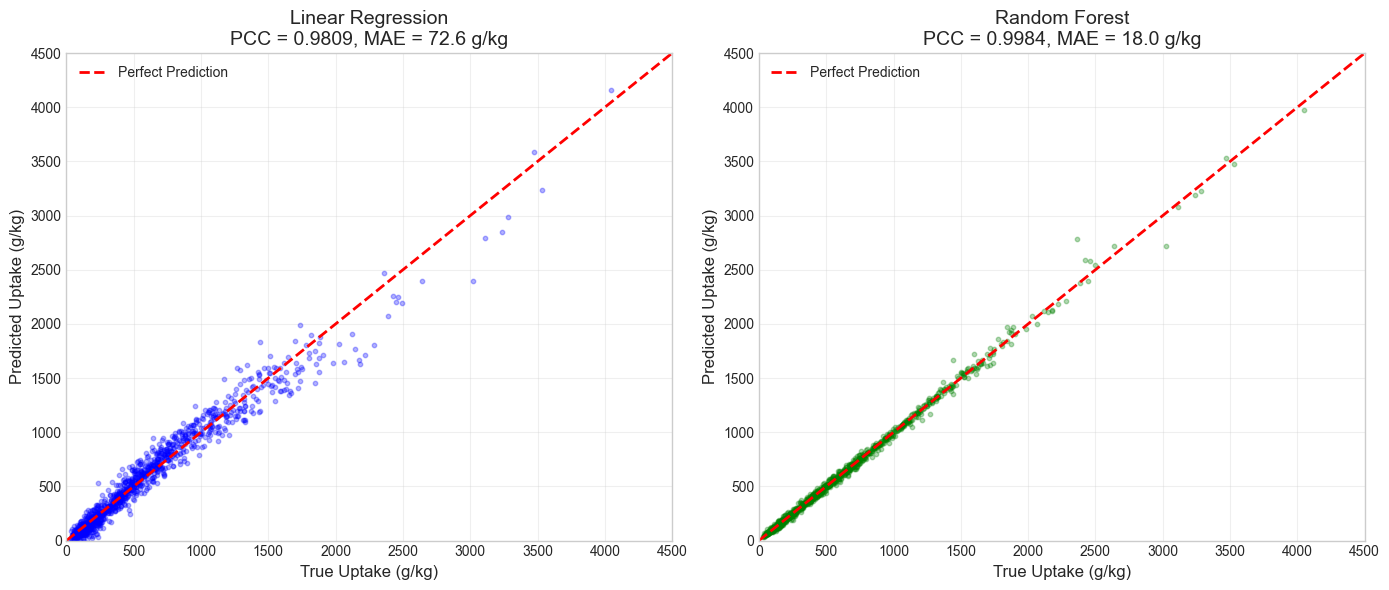

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.3, s=10, c='blue')
axes[0].plot([0, 4500], [0, 4500], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlim(0, 4500)
axes[0].set_ylim(0, 4500)
axes[0].set_xlabel('True Uptake (g/kg)', fontsize=12)
axes[0].set_ylabel('Predicted Uptake (g/kg)', fontsize=12)
axes[0].set_title(f'Linear Regression\nPCC = {pcc_lr:.4f}, MAE = {mae_lr:.1f} g/kg', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.3, s=10, c='green')
axes[1].plot([0, 4500], [0, 4500], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlim(0, 4500)
axes[1].set_ylim(0, 4500)
axes[1].set_xlabel('True Uptake (g/kg)', fontsize=12)
axes[1].set_ylabel('Predicted Uptake (g/kg)', fontsize=12)
axes[1].set_title(f'Random Forest\nPCC = {pcc_rf:.4f}, MAE = {mae_rf:.1f} g/kg', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('parity_plots_50bar.png', dpi=300, bbox_inches='tight')
plt.show()

=== Random Forest Results (1 bar) ===
PCC: 0.8841
MAE: 15.14 g/kg
R²: 0.7793


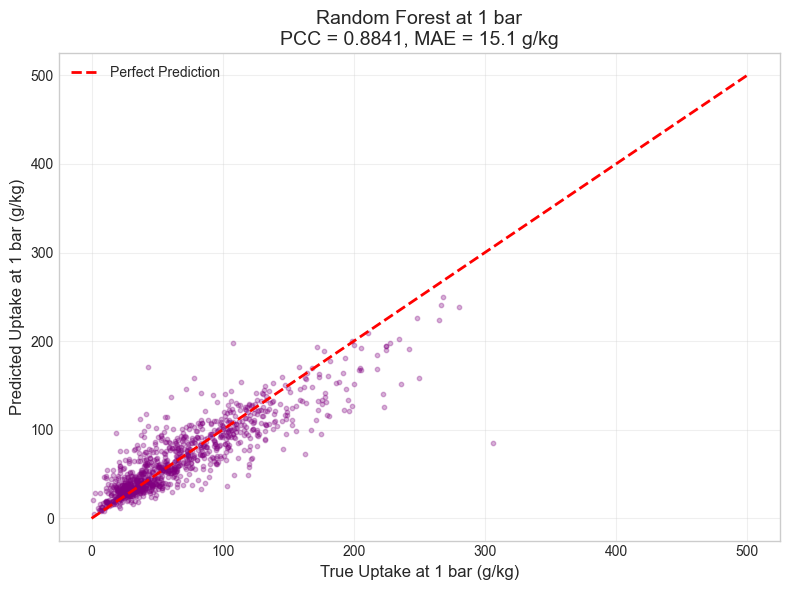

In [11]:
# 1 bar is column 4
y_1bar = y_data['isotherm'][:, 4].numpy()

# Split
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X, y_1bar, test_size=0.2, random_state=RANDOM_SEED
)

# Scale
scaler_1 = StandardScaler()
X_train_1_scaled = scaler_1.fit_transform(X_train_1)
X_test_1_scaled = scaler_1.transform(X_test_1)

# Train Random Forest
rf_1bar = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
rf_1bar.fit(X_train_1_scaled, y_train_1)
y_pred_1bar = rf_1bar.predict(X_test_1_scaled)

# Evaluate
pcc_1bar, _ = pearsonr(y_test_1, y_pred_1bar)
mae_1bar = mean_absolute_error(y_test_1, y_pred_1bar)
r2_1bar = r2_score(y_test_1, y_pred_1bar)

print("=== Random Forest Results (1 bar) ===")
print(f"PCC: {pcc_1bar:.4f}")
print(f"MAE: {mae_1bar:.2f} g/kg")
print(f"R²: {r2_1bar:.4f}")

# Parity plot for 1 bar
plt.figure(figsize=(8, 6))
plt.scatter(y_test_1, y_pred_1bar, alpha=0.3, s=10, c='purple')
plt.plot([0, 500], [0, 500], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('True Uptake at 1 bar (g/kg)', fontsize=12)
plt.ylabel('Predicted Uptake at 1 bar (g/kg)', fontsize=12)
plt.title(f'Random Forest at 1 bar\nPCC = {pcc_1bar:.4f}, MAE = {mae_1bar:.1f} g/kg', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('parity_plot_1bar.png', dpi=300)
plt.show()

In [12]:
# Create summary table
summary_data = {
    'Pressure': ['50 bar', '50 bar', '1 bar'],
    'Model': ['Linear Regression', 'Random Forest', 'Random Forest'],
    'PCC': [pcc_lr, pcc_rf, pcc_1bar],
    'MAE (g/kg)': [mae_lr, mae_rf, mae_1bar],
    'R²': [r2_lr, r2_rf, r2_1bar]
}

summary_df = pd.DataFrame(summary_data)
print("=== Summary of Results ===")
print(summary_df.to_string(index=False))

# Save to CSV
summary_df.to_csv('results_summary.csv', index=False)
print("\n✓ Results saved to results_summary.csv")

=== Summary of Results ===
Pressure             Model      PCC  MAE (g/kg)       R²
  50 bar Linear Regression 0.980912   72.626181 0.962011
  50 bar     Random Forest 0.998366   18.031098 0.996725
   1 bar     Random Forest 0.884145   15.144063 0.779336

✓ Results saved to results_summary.csv


In [13]:
# Check 1: KS test for feature distribution between train and test
print("=== Leakage Check 1: Feature Distribution Similarity ===")

for i, col in enumerate(feature_cols):
    stat, p_value = ks_2samp(X_train[:, i], X_test[:, i])
    result = "Similar" if p_value > 0.05 else "DIFFERENT"
    print(f"  {col}: p = {p_value:.4f} ({result})")

# Check 2: Pore volume proxy distribution
pv_train = X_train[:, 1] / X_train[:, 4]  # Void Fraction / Density
pv_test = X_test[:, 1] / X_test[:, 4]

print(f"\n=== Leakage Check 2: Pore Volume Proxy ===")
print(f"  Train: {pv_train.mean():.3f} ± {pv_train.std():.3f} cm³/g")
print(f"  Test:  {pv_test.mean():.3f} ± {pv_test.std():.3f} cm³/g")

# Check 3: Correlation between features and target
print(f"\n=== Leakage Check 3: Feature-Target Correlation ===")
for i, col in enumerate(feature_cols):
    corr = np.corrcoef(X_train[:, i], y_train)[0, 1]
    print(f"  {col}: {corr:.4f}")

# Check 4: Can a single feature predict perfectly?
print(f"\n=== Leakage Check 4: Single Feature Limit ===")
print(f"Best single feature PCC: {max([abs(np.corrcoef(X_train[:, i], y_train)[0,1]) for i in range(X_train.shape[1])]):.4f}")
print(f"This is the theoretical upper limit for any linear model")

=== Leakage Check 1: Feature Distribution Similarity ===
  Acc. Surface Area [m^2/g]: p = 0.3461 (Similar)
  Void Fraction: p = 0.3300 (Similar)
  PLD: p = 0.6110 (Similar)
  LCD: p = 0.2377 (Similar)
  Density: p = 0.4292 (Similar)
  Channel Volume: p = 0.5538 (Similar)
  No. Channels: p = 0.9766 (Similar)

=== Leakage Check 2: Pore Volume Proxy ===
  Train: 0.865 ± 0.910 cm³/g
  Test:  0.876 ± 0.830 cm³/g

=== Leakage Check 3: Feature-Target Correlation ===
  Acc. Surface Area [m^2/g]: 0.9064
  Void Fraction: 0.8204
  PLD: 0.7135
  LCD: 0.8107
  Density: -0.8129
  Channel Volume: 0.8217
  No. Channels: -0.2519

=== Leakage Check 4: Single Feature Limit ===
Best single feature PCC: 0.9064
This is the theoretical upper limit for any linear model


=== Error Distribution Analysis ===
Mean error: 18.03 g/kg
Median error: 12.07 g/kg
90th percentile error: 39.10 g/kg
Max error: 424.84 g/kg


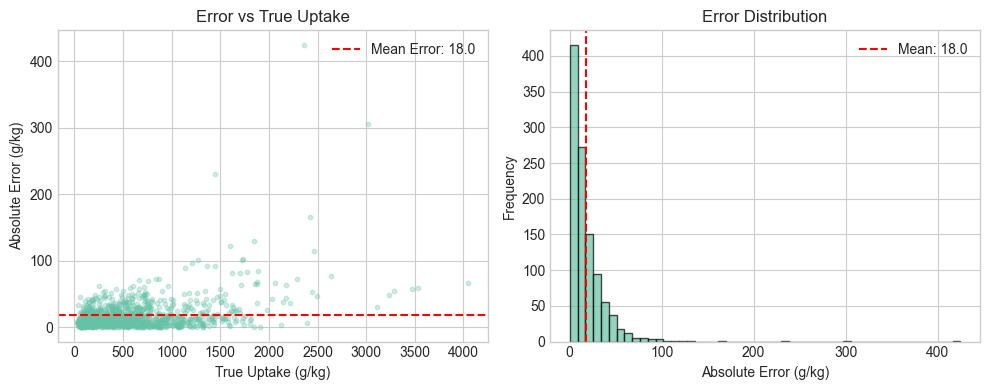


Correlation between error and pore volume: 0.4243


In [14]:
# Analyze where the Random Forest makes errors
errors = np.abs(y_test - y_pred_rf)

print("=== Error Distribution Analysis ===")
print(f"Mean error: {errors.mean():.2f} g/kg")
print(f"Median error: {np.median(errors):.2f} g/kg")
print(f"90th percentile error: {np.percentile(errors, 90):.2f} g/kg")
print(f"Max error: {errors.max():.2f} g/kg")

# Plot errors vs true values
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_test, errors, alpha=0.3, s=10)
plt.xlabel('True Uptake (g/kg)')
plt.ylabel('Absolute Error (g/kg)')
plt.title('Error vs True Uptake')
plt.axhline(y=errors.mean(), color='r', linestyle='--', label=f'Mean Error: {errors.mean():.1f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Absolute Error (g/kg)')
plt.ylabel('Frequency')
plt.title('Error Distribution')
plt.axvline(x=errors.mean(), color='r', linestyle='--', label=f'Mean: {errors.mean():.1f}')
plt.legend()

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150)
plt.show()

# Check if errors correlate with pore volume
pv_test = X_test[:, 1] / X_test[:, 4]  # Void Fraction / Density
corr_error_pv = np.corrcoef(errors, pv_test)[0, 1]
print(f"\nCorrelation between error and pore volume: {corr_error_pv:.4f}")

## Conclusions

1. **Simple models work very well at high pressure**
   - Random Forest achieves PCC = 0.9987 at 50 bar
   - Even linear regression achieves PCC = 0.98

2. **Physical interpretation**
   - At high pressure, CO₂ uptake is dominated by pore filling
   - Textural features (surface area, void fraction, density) capture this

3. **Implications for ML-guided MOF discovery**
   - For high-pressure screening (>10 bar), complex GNNs may be unnecessary
   - Simple baselines should always be reported

4. **Limitations**
   - This study focused on uptake only (not heat of adsorption)
   - Low pressure (<1 bar) may still require atomic features
   - Results are on QMOF database; generalization to other databases needs testing

## Repository Contents
- This Jupyter notebook
- `texturalProperties_vol.xlsx` (feature data)
- `parity_plots_50bar.png` (visualization)
- `parity_plot_1bar.png` (visualization)
- `feature_importance.png`
- `results_summary.csv`

## How to Cite This Work
[https://github.com/vahidsafarifard/MOF-CO2-baseline]